### **`Module Importation`**

In [70]:
import pandas as pd
import sklearn
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from matplotlib import colormaps
sns.set_palette('Set2')
sns.set_style("darkgrid")
from warnings import filterwarnings
filterwarnings(action="ignore")
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,OrdinalEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix, precision_score, recall_score, accuracy_score, f1_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import FunctionTransformer
import pickle
import joblib
import os

Loading the data from specified path into a pandas DataFrame.

In [2]:
file_path = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'

# Load the data into a pandas DataFrame
try:
    df = pd.read_csv(file_path)
    print(f"Data loaded successfully from {file_path}.")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file at {file_path} was not found. Please check the path and try again.")
except Exception as e:
    print(f"An error occurred while loading the data: {e}")

Data loaded successfully from WA_Fn-UseC_-Telco-Customer-Churn.csv.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### **`Exploratory Analysis`** ###

In this section, investigation into the dataset is carried out before any modelling is done.
Investigation carried out to determine the datset's:
- Number of rows
- Number of columns
- Data types
- Target variable
- Numerical variables
- Categorical variables
- Missing values
- Duplicate records

In [7]:
df.shape

(7043, 21)

In [3]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.dtypes.value_counts()

str        18
int64       2
float64     1
Name: count, dtype: int64

In [5]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**`The dataset possesses the following features:`**
- 16 object features and 3 numeric features
- 7043 rows and 21 columns
- No null values
- The target feature is the feature 'churn', represented as yes and no

### **`Data Cleaning`** ###

In [8]:
# Convert column 'TotalCharges' to numeric type
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors="coerce")


### **`Visualisations`**

In [21]:
revenues = df.pivot_table(columns="Contract", aggfunc={"TotalCharges":"sum", "MonthlyCharges":"sum"}).T
revenues["TotalRevenues"] = revenues["MonthlyCharges"] + revenues["TotalCharges"]
revenues

,MonthlyCharges,TotalCharges,TotalRevenues
Contract,,,
Month-to-month,257294.15,5305861.5,5563155.65
One year,95816.60,4467053.5,4562870.10
Two year,103005.85,6283253.7,6386259.55


##### The major source of revenue for the Telco is from Two year contracts, then shorter, month-to-month contracts, and then One Year contract offerings

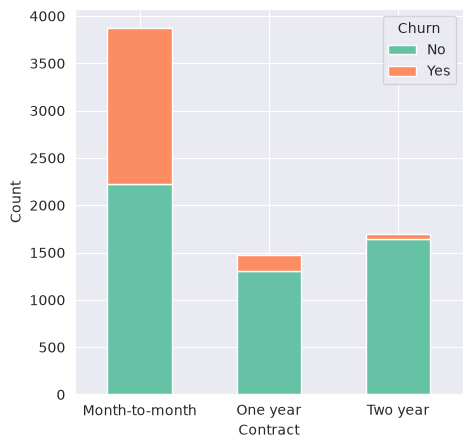

In [71]:
df.groupby(["Contract", "Churn"]).size().unstack().plot(
    kind="bar",
    stacked=True,
    figsize=(5, 5)
)

plt.xlabel("Contract")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

    The diagram above shows that amongst the three contract offerings to customers,customers subscribed on a month-to-month basis are at the highest risk of churn, with almost half their number exiting the Telco's services

In [116]:
df["SeniorCitizen"].value_counts(normalize = True)

SeniorCitizen
0    0.837853
1    0.162147
Name: proportion, dtype: float64

    The diagram below shows that most of the Telco's subscribers are young or middle-aged(84%), and as a result, most of the customers who churn are disproportionately from this group. 

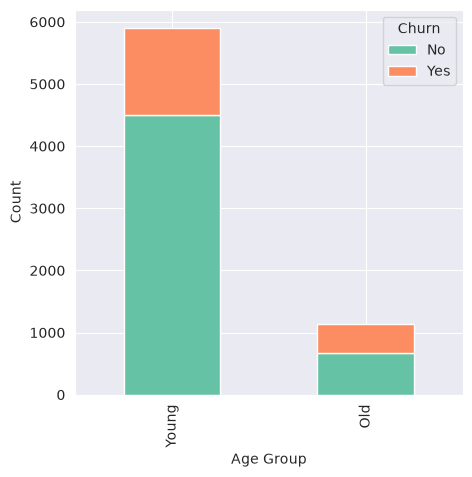

In [72]:
df.groupby(["SeniorCitizen", "Churn"]).size().unstack().plot(
    kind="bar",
    stacked=True,
    figsize=(5, 5)
    );

plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks([0, 1],["Young", "Old"])
plt.show()

In [24]:
newer_customers = df[df["tenure"] <= 6]
older_customers = df[df["tenure"] > 6]


In [98]:
print(f"Older Customer split(> 6 months):\n {pd.concat([older_customers["Churn"].value_counts(), older_customers["Churn"].value_counts(normalize = True)], axis=1)}\n")
print(f"Newer Customer Split(=< 6 months):\n {pd.concat([newer_customers["Churn"].value_counts(), newer_customers["Churn"].value_counts(normalize = True)], axis=1)}\n")

Older Customer split(> 6 months):
        count  proportion
Churn                   
No      4477    0.804926
Yes     1085    0.195074

Newer Customer Split(=< 6 months):
        count  proportion
Churn                   
Yes      784    0.529372
No       697    0.470628



    The tables above show, that majorty of the Telco's subscribers have used their services in excess of 6 months(5562 against 1481), but customers on their books for 6 months or less switched providers two and a half times more ((0.52) against (0.19)), than longer term subscribers.

### **`Preprocessing`**

In [99]:
def data_preprocessor(df):

    df = df.copy()

    # Convert TotalCharges to numeric
    df["TotalCharges"] = pd.to_numeric(
        df["TotalCharges"],
        errors="coerce"
    )

    df["TotalCharges"] = df["TotalCharges"].fillna(0)

    # Drop unnecessary columns
    X = df.drop(
        columns=[
            "customerID",
            "PaymentMethod",
            "PaperlessBilling",
            "Churn"
        ],
        errors="ignore"
    )

    # Binary encoding
    X["gender"] = X["gender"].apply(
        lambda x: 1 if x == "Male" else 0
    )

    yes_no_cols = [
        "MultipleLines",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
        "Partner",
        "Dependents",
        "PhoneService"
    ]

    for col in yes_no_cols:
        X[col] = X[col].apply(
            lambda x: 1 if x == "Yes" else 0
        )

    # Categorical encoding
    X["InternetService"] = X["InternetService"].apply(
        lambda x:
            2 if x == "Fiber optic"
            else 1 if x == "DSL"
            else 0
    )

    X["Contract"] = X["Contract"].apply(
        lambda x:
            1 if x == "Month-to-month"
            else 2 if x == "One year"
            else 3
    )

    return X

### **`Train-Test-Split`**

In [100]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop("Churn", axis=1),
    df["Churn"],
    test_size=0.2,
    random_state=42
)

### **`Model Selection`**

In [101]:
models = {
    "LogisticRegression": LogisticRegression(),

    "DecisionTreeClassifier":
        DecisionTreeClassifier(random_state=42),

    "RandomForestClassifier":
        RandomForestClassifier(random_state=42),

    "KNeighboursClassifier":
        KNeighborsClassifier(),

    "SupportVectorClassifier":
        SVC(probability=True, random_state=42),

    "VotingClassifier":
        VotingClassifier(
            voting="hard",
            estimators=[
                ("lr", LogisticRegression()),
                ("dt", DecisionTreeClassifier(random_state=42)),
                ("rf", RandomForestClassifier(random_state=42)),
                ("knn", KNeighborsClassifier()),
                ("svc", SVC(probability=True, random_state=42))
            ]
        )
}

Result_1: LogisticRegression
TRAINING RESULTS
Precision: 0.6477
Recall:    0.5187
Accuracy:  0.7973
F1 Score:  0.5761

TEST RESULTS
              precision    recall  f1-score   support

          No       0.85      0.90      0.88      1036
         Yes       0.68      0.56      0.61       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.75      1409
weighted avg       0.80      0.81      0.81      1409



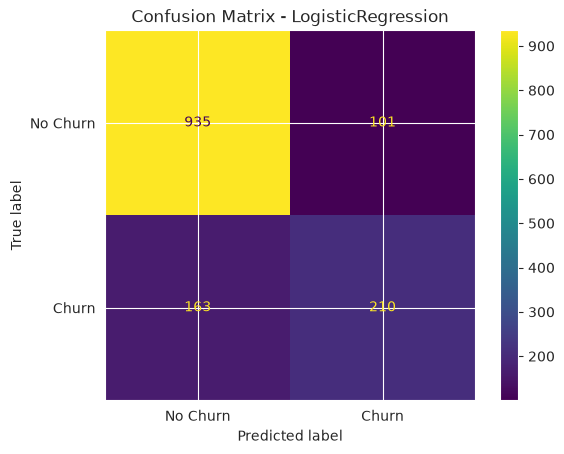


Result_2: DecisionTreeClassifier
TRAINING RESULTS
Precision: 0.9966
Recall:    0.9886
Accuracy:  0.9961
F1 Score:  0.9926

TEST RESULTS
              precision    recall  f1-score   support

          No       0.81      0.82      0.81      1036
         Yes       0.48      0.47      0.48       373

    accuracy                           0.73      1409
   macro avg       0.65      0.64      0.65      1409
weighted avg       0.72      0.73      0.72      1409



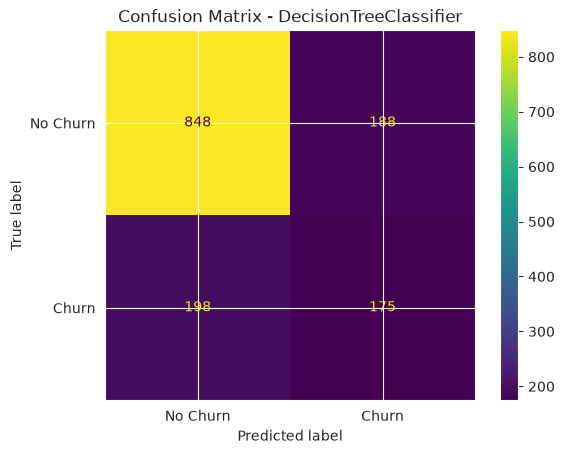


Result_3: RandomForestClassifier
TRAINING RESULTS
Precision: 0.9900
Recall:    0.9947
Accuracy:  0.9959
F1 Score:  0.9923

TEST RESULTS
              precision    recall  f1-score   support

          No       0.83      0.90      0.86      1036
         Yes       0.64      0.49      0.55       373

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



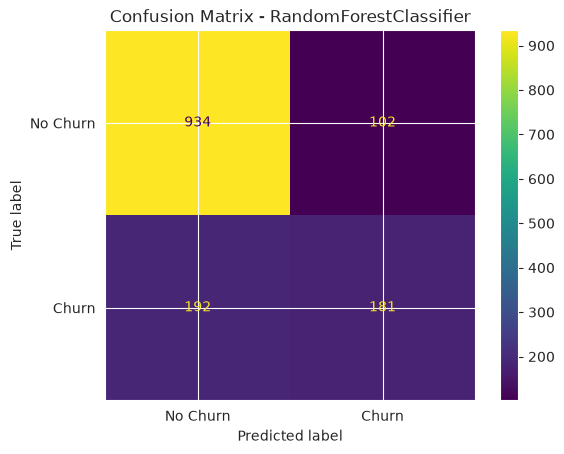


Result_4: KNeighboursClassifier
TRAINING RESULTS
Precision: 0.7392
Recall:    0.5515
Accuracy:  0.8293
F1 Score:  0.6317

TEST RESULTS
              precision    recall  f1-score   support

          No       0.82      0.89      0.86      1036
         Yes       0.61      0.47      0.53       373

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



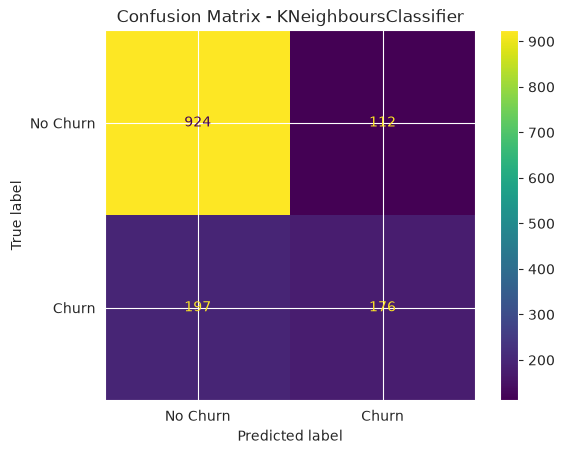


Result_5: SupportVectorClassifier
TRAINING RESULTS
Precision: 0.0000
Recall:    0.0000
Accuracy:  0.7345
F1 Score:  0.0000

TEST RESULTS
              precision    recall  f1-score   support

          No       0.74      1.00      0.85      1036
         Yes       0.00      0.00      0.00       373

    accuracy                           0.74      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.74      0.62      1409



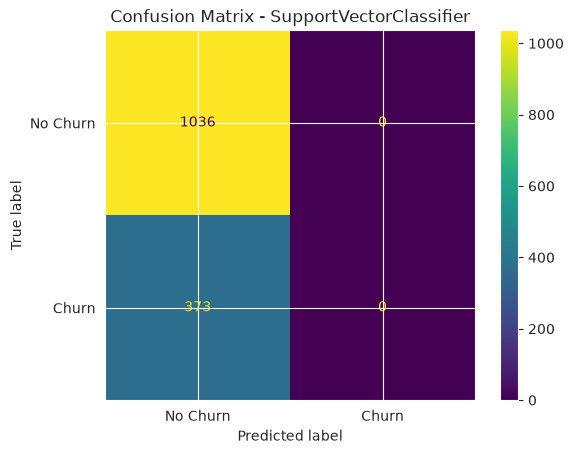


Result_6: VotingClassifier
TRAINING RESULTS
Precision: 0.9961
Recall:    0.6832
Accuracy:  0.9152
F1 Score:  0.8105

TEST RESULTS
              precision    recall  f1-score   support

          No       0.82      0.93      0.87      1036
         Yes       0.69      0.42      0.52       373

    accuracy                           0.79      1409
   macro avg       0.75      0.67      0.69      1409
weighted avg       0.78      0.79      0.78      1409



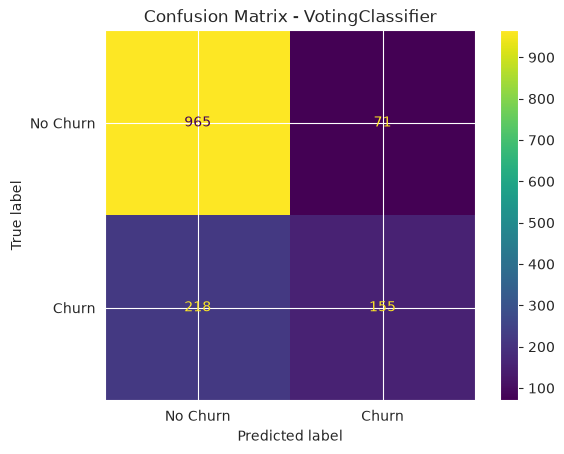

In [103]:
counter = 0
model_names = []
accuracy = []
f1_scores = []
recall = []
precision = []
for model_name, model in models.items():

    pipe = Pipeline([
        ("custom cleaner", FunctionTransformer(data_preprocessor)),
        ("model", model)
    ])

    # Train
    pipe.fit(X_train, y_train)

    # Predict ONCE
    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)

    # Training metrics
    train_precision = precision_score(
        y_train,
        y_train_pred,
        pos_label="Yes"
    )

    train_recall = recall_score(
        y_train,
        y_train_pred,
        pos_label="Yes"
    )

    train_accuracy = accuracy_score(
        y_train,
        y_train_pred
    )

    train_f1 = f1_score(
        y_train,
        y_train_pred,
        pos_label="Yes"
    )

    # Test report
    test_report = classification_report(
        y_test,
        y_test_pred
    )

    print(f"Result_{counter + 1}: {model_name}")
    print("=" * 60)

    print("TRAINING RESULTS")
    print(f"Precision: {train_precision:.4f}")
    print(f"Recall:    {train_recall:.4f}")
    print(f"Accuracy:  {train_accuracy:.4f}")
    print(f"F1 Score:  {train_f1:.4f}")

    print("\nTEST RESULTS")
    print(test_report)

    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_test_pred,
        display_labels=["No Churn", "Churn"]
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    print("=" * 60)
    print()
    model_names.append(model_name)
    precision.append(train_precision)
    recall.append(train_recall)
    accuracy.append(train_accuracy)
    f1_scores.append(train_f1)

    counter += 1

In [105]:
training_results = pd.DataFrame({"Model_Name":model_names,"Accuracy_Score":accuracy,
"F1_scores":f1_scores,
"Recall_Score":recall,
"Precision_Scores":precision})

In [118]:
training_results

,Model_Name,Accuracy_Score,F1_scores,Recall_Score,Precision_Scores
0,LogisticRegression,0.797302,0.576095,0.518717,0.647746
1,DecisionTreeClassifier,0.996095,0.992617,0.988636,0.996631
2,RandomForestClassifier,0.995918,0.992331,0.994652,0.990020
3,KNeighboursClassifier,0.829251,0.631700,0.551471,0.739247
4,SupportVectorClassifier,0.734469,0.000000,0.000000,0.000000
5,VotingClassifier,0.915158,0.810468,0.683155,0.996101


### **`Model Evaluation`**

The VotingClassifier model is the chosen model to run the application for the following reasons:
- It combines the best of the other classifiers in it's construction, taking weak learners and making a strong one.
- The primary metric by which the model is being judged is _precision_. Of all the models trained, it possesses the highest precision relative to it's F1-score
- From a business standpoint, it makes logical sense. The firm's desire should be to be accurate as possible in predicting who is most at risk of churn, in order to put strategies in place to prevent subscriber loss